## Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import re
import string
import json
import csv
import requests
from io import StringIO
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, precision_score

In [5]:
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Load Dataset

In [6]:
dataset = pd.read_csv('dataset/review_app_brimo.csv')
dataset.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,ddb851eb-4872-4940-bbb3-2ab1df4623df,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,ok,5,0,2.95.1,2026-04-26 22:13:11,"Hai Sobat BRI, terima kasih atas ulasannya. Se...",2026-04-26 22:35:51,2.95.1
1,34385a2a-7cf4-4f15-a708-29d390138ae4,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,ok,5,0,2.94.0,2026-04-26 22:07:45,"Hai Sobat BRI, terima kasih atas ulasannya. Se...",2026-04-26 22:35:17,2.94.0
2,178081a0-9661-43ec-a9f2-eae32e0c89cd,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,lancar dan cepat,5,0,2.95.1,2026-04-26 22:07:39,"Hai Sobat BRI, terima kasih atas ulasannya. Se...",2026-04-26 22:32:53,2.95.1
3,4e187f0c-c86e-4f3c-b001-e0a344e1c096,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,tolong di aplikasi brimo dikasih buat printer....,5,0,2.95.1,2026-04-26 22:00:14,"Hai Sobat BRI, terima kasih atas ulasannya. Ha...",2026-04-26 22:15:22,2.95.1
4,9f209278-060b-4132-9356-68f77ca6e573,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mudah dan praktis,5,0,2.95.1,2026-04-26 21:59:21,"Hai Sobat BRI, terima kasih atas ulasannya. Se...",2026-04-26 22:19:14,2.95.1


In [7]:
# Menghitung jumlah baris dan kolom dalam DataFrame
jumlah_ulasan, jumlah_kolom = dataset.shape

print(jumlah_ulasan)
print(jumlah_kolom)

20000
11


In [8]:
# Menampilkan informasi dataset
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              20000 non-null  object
 1   userName              20000 non-null  object
 2   userImage             20000 non-null  object
 3   content               20000 non-null  object
 4   score                 20000 non-null  int64 
 5   thumbsUpCount         20000 non-null  int64 
 6   reviewCreatedVersion  16373 non-null  object
 7   at                    20000 non-null  object
 8   replyContent          19836 non-null  object
 9   repliedAt             19836 non-null  object
 10  appVersion            16373 non-null  object
dtypes: int64(2), object(9)
memory usage: 1.7+ MB


## Preprocessing

#### Data Cleaning

In [9]:
# Mengecek nilai kosong pada dataset
dataset.isnull().sum()

reviewId                   0
userName                   0
userImage                  0
content                    0
score                      0
thumbsUpCount              0
reviewCreatedVersion    3627
at                         0
replyContent             164
repliedAt                164
appVersion              3627
dtype: int64

In [10]:
# Membuat DataFrame baru (clean_df) dengan menghapus baris yang memiliki nilai yang hilang (NaN)  dari dataset
clean_df = dataset.dropna()

#Menghapus data yang duplikat dari dataset
clean_df.drop_duplicates()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,ddb851eb-4872-4940-bbb3-2ab1df4623df,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,ok,5,0,2.95.1,2026-04-26 22:13:11,"Hai Sobat BRI, terima kasih atas ulasannya. Se...",2026-04-26 22:35:51,2.95.1
1,34385a2a-7cf4-4f15-a708-29d390138ae4,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,ok,5,0,2.94.0,2026-04-26 22:07:45,"Hai Sobat BRI, terima kasih atas ulasannya. Se...",2026-04-26 22:35:17,2.94.0
2,178081a0-9661-43ec-a9f2-eae32e0c89cd,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,lancar dan cepat,5,0,2.95.1,2026-04-26 22:07:39,"Hai Sobat BRI, terima kasih atas ulasannya. Se...",2026-04-26 22:32:53,2.95.1
3,4e187f0c-c86e-4f3c-b001-e0a344e1c096,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,tolong di aplikasi brimo dikasih buat printer....,5,0,2.95.1,2026-04-26 22:00:14,"Hai Sobat BRI, terima kasih atas ulasannya. Ha...",2026-04-26 22:15:22,2.95.1
4,9f209278-060b-4132-9356-68f77ca6e573,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mudah dan praktis,5,0,2.95.1,2026-04-26 21:59:21,"Hai Sobat BRI, terima kasih atas ulasannya. Se...",2026-04-26 22:19:14,2.95.1
...,...,...,...,...,...,...,...,...,...,...,...
19993,886cfd6e-b2f5-4568-9a96-2c72adf57921,Apud Saepudin,https://play-lh.googleusercontent.com/a/ACg8oc...,mantul,5,0,2.93.0,2026-02-21 04:31:43,"Hai Sobat BRI, terima kasih atas ulasannya ☺️....",2026-02-21 05:24:28,2.93.0
19994,d94d531e-6194-4642-b3e8-b3c5e9368c42,Kandang Ayam,https://play-lh.googleusercontent.com/a/ACg8oc...,bagus cepat tepat dalam semua transaksi,5,0,2.93.0,2026-02-21 04:31:18,"Hai Sobat BRI, terima kasih atas ulasannya ☺️....",2026-02-21 04:39:00,2.93.0
19995,3b3b5a0c-ab74-4382-a813-3dd9c2bf090a,Dewi Indriani,https://play-lh.googleusercontent.com/a-/ALV-U...,"bagus,mudah dan simpel semua pakai brimo",5,0,2.93.0,2026-02-21 04:30:08,"Hai Sobat BRI, terima kasih atas ulasannya ☺️....",2026-02-21 04:35:18,2.93.0
19997,6129c0c2-b108-485e-bf52-8864b2beb06d,Setyawan Wakry,https://play-lh.googleusercontent.com/a-/ALV-U...,tidak bisa di gunakan lg apl nya payah,1,0,2.93.0,2026-02-21 04:10:42,"Hai Sobat BRI, mohon maaf atas kendala yang di...",2026-02-21 04:35:50,2.93.0


In [11]:
# Menampilkan informasi tentang DataFrame clean_df setelah membersihkan nilai yang hilang (NaN)
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16242 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              16242 non-null  object
 1   userName              16242 non-null  object
 2   userImage             16242 non-null  object
 3   content               16242 non-null  object
 4   score                 16242 non-null  int64 
 5   thumbsUpCount         16242 non-null  int64 
 6   reviewCreatedVersion  16242 non-null  object
 7   at                    16242 non-null  object
 8   replyContent          16242 non-null  object
 9   repliedAt             16242 non-null  object
 10  appVersion            16242 non-null  object
dtypes: int64(2), object(9)
memory usage: 1.5+ MB


In [12]:
# Fungsi untuk membersihkan teks dari simbol, angka, dll
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) 
    text = re.sub(r'#[A-Za-z0-9]+', '', text) 
    text = re.sub(r'RT[\s]', '', text) 
    text = re.sub(r"http\S+", '', text) 
    text = re.sub(r'[0-9]+', '', text) 
    text = re.sub(r'[^\w\s]', '', text) 


    text = text.replace('\n', ' ') 
    text = text.translate(str.maketrans('', '', string.punctuation)) 
    text = text.strip(' ') #
    return text

# Fungsi untuk merubah semua karakter menjadi lower case
def casefoldingText(text): 
    text = text.lower()
    return text

# Fungsi untuk membagi teks menjadi token
def tokenizingText(text): 
    text = word_tokenize(text)
    return text

# Fungsi untuk memfilter stopwords
def filteringText(text): 
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords1 = set(stopwords.words('english'))
    listStopwords.update(listStopwords1)
    listStopwords.update(['iya','yaa','gak','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah","woi","woii","woy"])
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text


# Fungsi untuk menggabungkan kata-kata menjadi kalimat
def toSentence(list_words): 
    sentence = ' '.join(word for word in list_words)
    return sentence

In [13]:
# Fungsi untuk menerapkan stemming pada teks
def stemmingText(text, stemmer_obj):
    return stemmer_obj.stem(text)

In [14]:
# Fungsi untuk memuat data JSON menjadi kamus 
def load_slangwords(filepath):
    with open(filepath, 'r', encoding='utf-8') as file:
        return json.load(file)


def fix_slangwords(text, slang_dict):
    words = text.split()
    return ' '.join([slang_dict.get(word.lower(), word) for word in words])

In [15]:
factory = StemmerFactory()
stemmer_sastrawi = factory.create_stemmer()
slangwords_dict = load_slangwords('dataset/slangwords.json')

# 1. Pembersihan teks awal
clean_df['text_clean'] = clean_df['content'].apply(cleaningText)

# 2. Mengubah menjadi huruf kecil (case folding)
clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)

# 3. Memperbaiki kata slang menggunakan lambda
clean_df['text_slangwords'] = clean_df['text_casefoldingText'].apply(lambda x: fix_slangwords(x, slangwords_dict))

# 4. Tokenisasi
clean_df['text_tokenizingText'] = clean_df['text_slangwords'].apply(tokenizingText)

# 5. Menghapus stopword
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(filteringText)

# 6. Menggabungkan kembali menjadi kalimat
clean_df['text_akhir'] = clean_df['text_stopword'].apply(toSentence)

# 7. Proses Stemming menggunakan lambda
clean_df['text_stemmed'] = clean_df['text_akhir'].apply(lambda x: stemmingText(x, stemmer_sastrawi))

C:\Users\ASUS\AppData\Local\Temp\ipykernel_22328\2612001588.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df['text_clean'] = clean_df['content'].apply(cleaningText)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_22328\2612001588.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_22328\2612001588.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice f

In [16]:
clean_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir,text_stemmed
0,ddb851eb-4872-4940-bbb3-2ab1df4623df,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,ok,5,0,2.95.1,2026-04-26 22:13:11,"Hai Sobat BRI, terima kasih atas ulasannya. Se...",2026-04-26 22:35:51,2.95.1,ok,ok,ok,[ok],[ok],ok,ok
1,34385a2a-7cf4-4f15-a708-29d390138ae4,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,ok,5,0,2.94.0,2026-04-26 22:07:45,"Hai Sobat BRI, terima kasih atas ulasannya. Se...",2026-04-26 22:35:17,2.94.0,ok,ok,ok,[ok],[ok],ok,ok
2,178081a0-9661-43ec-a9f2-eae32e0c89cd,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,lancar dan cepat,5,0,2.95.1,2026-04-26 22:07:39,"Hai Sobat BRI, terima kasih atas ulasannya. Se...",2026-04-26 22:32:53,2.95.1,lancar dan cepat,lancar dan cepat,lancar dan cepat,"[lancar, dan, cepat]","[lancar, cepat]",lancar cepat,lancar cepat
3,4e187f0c-c86e-4f3c-b001-e0a344e1c096,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,tolong di aplikasi brimo dikasih buat printer....,5,0,2.95.1,2026-04-26 22:00:14,"Hai Sobat BRI, terima kasih atas ulasannya. Ha...",2026-04-26 22:15:22,2.95.1,tolong di aplikasi brimo dikasih buat printerb...,tolong di aplikasi brimo dikasih buat printerb...,tolong di aplikasi brimo dikasih buat printerb...,"[tolong, di, aplikasi, brimo, dikasih, buat, p...","[tolong, aplikasi, brimo, dikasih, printerbiar...",tolong aplikasi brimo dikasih printerbiar baya...,tolong aplikasi brimo kasih printerbiar bayar ...
4,9f209278-060b-4132-9356-68f77ca6e573,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mudah dan praktis,5,0,2.95.1,2026-04-26 21:59:21,"Hai Sobat BRI, terima kasih atas ulasannya. Se...",2026-04-26 22:19:14,2.95.1,mudah dan praktis,mudah dan praktis,mudah dan praktis,"[mudah, dan, praktis]","[mudah, praktis]",mudah praktis,mudah praktis


In [67]:
def load_lexicon_from_github(url):
    lexicon_dict = {}
    
    try:
        response = requests.get(url)

        if response.status_code == 200:
            reader = csv.reader(StringIO(response.text), delimiter=',')
            
            for row in reader:
                if len(row) >= 2:
                    lexicon_dict[row[0]] = int(row[1])
                    
            return lexicon_dict
        else:
            print(f"Gagal mengunduh leksikon. Kode Status HTTP: {response.status_code} untuk URL: {url}")
            return {}
            
    except requests.exceptions.RequestException as e:
        print(f"Terjadi kesalahan koneksi jaringan: {e}")
        return {}

In [68]:
url_pos = 'https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv'
url_neg = 'https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv'

lexicon_positive = load_lexicon_from_github(url_pos)
lexicon_negative = load_lexicon_from_github(url_neg)

# (Opsional) Memverifikasi jumlah kata yang berhasil dimuat
print(f"Total kata positif termuat : {len(lexicon_positive)}")
print(f"Total kata negatif termuat : {len(lexicon_negative)}")

Total kata positif termuat : 3609
Total kata negatif termuat : 6607


## Labeling Data

In [69]:
def sentiment_analysis_lexicon_indonesia(text, lex_positive, lex_negative):
    if isinstance(text, str):
        words = text.split()
    else:
        words = text
    score = 0
    for word in words:
        score += lex_positive.get(word, 0)
        score += lex_negative.get(word, 0) 
    if score > 0:
        polarity = 'positive'
    else:
        polarity = 'negative'
    return score, polarity

In [71]:
results = clean_df['text_stopword'].apply(lambda x: sentiment_analysis_lexicon_indonesia(x, lexicon_positive, lexicon_negative))
results = list(zip(*results))
clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]
print(clean_df['polarity'].value_counts())

polarity
negative    8577
positive    7665
Name: count, dtype: int64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_22328\3328536697.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df['polarity_score'] = results[0]
C:\Users\ASUS\AppData\Local\Temp\ipykernel_22328\3328536697.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df['polarity'] = results[1]


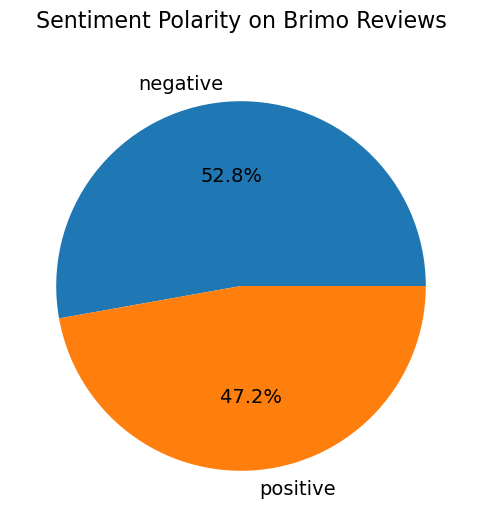

In [55]:

fig, ax = plt.subplots(figsize=(6, 6))

sizes = clean_df['polarity'].value_counts().tolist()
labels = clean_df['polarity'].value_counts().index.tolist()
explode = (0 , 0) 
ax.pie(x=sizes, labels=labels, autopct='%1.1f%%', explode=explode, textprops={'fontsize': 14})
ax.set_title('Sentiment Polarity on Brimo Reviews', fontsize=16, pad=20)
plt.show()

In [72]:
clean_df.head(2)

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir,text_stemmed,polarity_score,polarity
0,ddb851eb-4872-4940-bbb3-2ab1df4623df,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,ok,5,0,2.95.1,2026-04-26 22:13:11,"Hai Sobat BRI, terima kasih atas ulasannya. Se...",2026-04-26 22:35:51,2.95.1,ok,ok,ok,[ok],[ok],ok,ok,4,positive
1,34385a2a-7cf4-4f15-a708-29d390138ae4,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,ok,5,0,2.94.0,2026-04-26 22:07:45,"Hai Sobat BRI, terima kasih atas ulasannya. Se...",2026-04-26 22:35:17,2.94.0,ok,ok,ok,[ok],[ok],ok,ok,4,positive


In [73]:
# Pisahkan data menjadi fitur (tweet) dan label (sentimen)
X = clean_df['text_akhir']
y = clean_df['polarity']

In [74]:
# Ekstraksi fitur dengan TF-IDF
tfidf = TfidfVectorizer(max_features=200, min_df=17, max_df=0.8 )
X_tfidf = tfidf.fit_transform(X)

In [75]:
# Konversi hasil ekstraksi fitur menjadi dataframe
features_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())

# Menampilkan hasil ekstraksi fitur
features_df

,admin,akses,akun,alhamdulillah,aman,aneh,apapun,apk,aplikasi,aplikasinya,...,uang,udh,ulang,update,urusan,username,verifikasi,wajah,warna,wifi
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.401685,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16237,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16238,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16239,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16240,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [76]:
# Bagi data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

In [77]:
from sklearn.naive_bayes import BernoulliNB

# Membuat objek model Naive Bayes (Bernoulli Naive Bayes)
naive_bayes = BernoulliNB()

# Melatih model Naive Bayes pada data pelatihan
naive_bayes.fit(X_train.toarray(), y_train)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_nb = naive_bayes.predict(X_train.toarray())
y_pred_test_nb = naive_bayes.predict(X_test.toarray())

# Evaluasi akurasi model Naive Bayes
accuracy_train_nb = accuracy_score(y_pred_train_nb, y_train)
accuracy_test_nb = accuracy_score(y_pred_test_nb, y_test)

# Menampilkan akurasi
print('Naive Bayes - accuracy_train:', accuracy_train_nb)
print('Naive Bayes - accuracy_test:', accuracy_test_nb)

Naive Bayes - accuracy_train: 0.8118217501731702
Naive Bayes - accuracy_test: 0.791320406278855


In [78]:
from sklearn.ensemble import RandomForestClassifier

# Membuat objek model Random Forest
random_forest = RandomForestClassifier()

# Melatih model Random Forest pada data pelatihan
random_forest.fit(X_train.toarray(), y_train)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_rf = random_forest.predict(X_train.toarray())
y_pred_test_rf = random_forest.predict(X_test.toarray())

# Evaluasi akurasi model Random Forest
accuracy_train_rf = accuracy_score(y_pred_train_rf, y_train)
accuracy_test_rf = accuracy_score(y_pred_test_rf, y_test)

# Menampilkan akurasi
print('Random Forest - accuracy_train:', accuracy_train_rf)
print('Random Forest - accuracy_test:', accuracy_test_rf)

Random Forest - accuracy_train: 0.9808358346802124
Random Forest - accuracy_test: 0.9341335795629424


In [79]:
from sklearn.linear_model import LogisticRegression

# Membuat objek model Logistic Regression
logistic_regression = LogisticRegression()

# Melatih model Logistic Regression pada data pelatihan
logistic_regression.fit(X_train.toarray(), y_train)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_lr = logistic_regression.predict(X_train.toarray())
y_pred_test_lr = logistic_regression.predict(X_test.toarray())

# Evaluasi akurasi model Logistic Regression pada data pelatihan
accuracy_train_lr = accuracy_score(y_pred_train_lr, y_train)

# Evaluasi akurasi model Logistic Regression pada data uji
accuracy_test_lr = accuracy_score(y_pred_test_lr, y_test)

# Menampilkan akurasi
print('Logistic Regression - accuracy_train:', accuracy_train_lr)
print('Logistic Regression - accuracy_test:', accuracy_test_lr)

Logistic Regression - accuracy_train: 0.9436619718309859
Logistic Regression - accuracy_test: 0.9449061249615266


In [80]:
from sklearn.tree import DecisionTreeClassifier

# Membuat objek model Decision Tree
decision_tree = DecisionTreeClassifier()

# Melatih model Decision Tree pada data pelatihan
decision_tree.fit(X_train.toarray(), y_train)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_dt = decision_tree.predict(X_train.toarray())
y_pred_test_dt = decision_tree.predict(X_test.toarray())

# Evaluasi akurasi model Decision Tree
accuracy_train_dt = accuracy_score(y_pred_train_dt, y_train)
accuracy_test_dt = accuracy_score(y_pred_test_dt, y_test)

# Menampilkan akurasi
print('Decision Tree - accuracy_train:', accuracy_train_dt)
print('Decision Tree - accuracy_test:', accuracy_test_dt)

Decision Tree - accuracy_train: 0.9808358346802124
Decision Tree - accuracy_test: 0.9193598030163127
